In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/alexeygrigorev/datasets/master/course_lead_scoring.csv')

In [3]:
df.head()

,lead_source,industry,number_of_courses_viewed,annual_income,employment_status,location,interaction_count,lead_score,converted
0,paid_ads,NaN,1,79450.0,unemployed,south_america,4,0.94,1
1,social_media,retail,1,46992.0,employed,south_america,1,0.80,0
2,events,healthcare,5,78796.0,unemployed,australia,3,0.69,1
3,paid_ads,retail,2,83843.0,NaN,australia,1,0.87,0
4,referral,education,3,85012.0,self_employed,europe,3,0.62,1


In [4]:
categorical = df.select_dtypes(include='str').columns.tolist()
numerical = df.select_dtypes(include='number').columns.tolist()

In [21]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

In [33]:
numeric_transformer = SimpleImputer(strategy='constant', fill_value = 0.0)
categorical_transformer = SimpleImputer(strategy='constant',fill_value='NA')

ct = ColumnTransformer([
    ("num", numeric_transformer, numerical),
    ("cat", categorical_transformer, categorical)
], verbose_feature_names_out=False)
ct.set_output(transform="pandas")
df_filled = ct.fit_transform(df)


In [34]:
df_filled['industry'].value_counts()

industry
retail           203
finance          200
other            198
healthcare       187
education        187
technology       179
manufacturing    174
NA               134
Name: count, dtype: int64

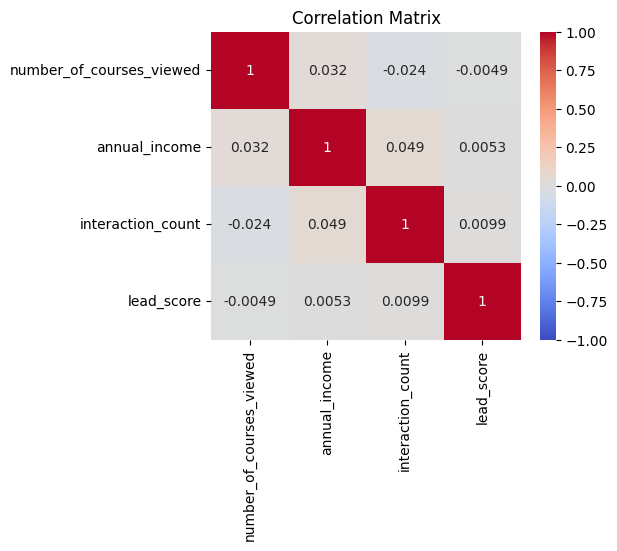

In [44]:
corr_matrix = df[numerical[:-1]].corr()
plt.figure(figsize=(5,4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Matrix")
plt.show()

In [45]:
corr_matrix.style.background_gradient(cmap='coolwarm', vmin=-1,vmax=1)

,number_of_courses_viewed,annual_income,interaction_count,lead_score
number_of_courses_viewed,1.000000,0.031551,-0.023565,-0.004879
annual_income,0.031551,1.000000,0.048618,0.005334
interaction_count,-0.023565,0.048618,1.000000,0.009888
lead_score,-0.004879,0.005334,0.009888,1.000000


In [60]:
from sklearn.model_selection import train_test_split

df_train_val, df_test = train_test_split(df_filled, test_size=0.2, random_state=42)
df_train, df_val = train_test_split(df_train_val, test_size=0.25, random_state=42)

print(f"Train: {len(df_train)}, Val: {len(df_val)}, Test: {len(df_test)}")

Train: 876, Val: 293, Test: 293


In [61]:
df_train.columns

Index(['number_of_courses_viewed', 'annual_income', 'interaction_count',
       'lead_score', 'converted', 'lead_source', 'industry',
       'employment_status', 'location'],
      dtype='str')

In [62]:
y_train = df_train['converted'].to_numpy()
df_train.drop(columns=['converted'], inplace=True)

y_val = df_val['converted'].to_numpy()
df_val.drop(columns=['converted'], inplace=True)

y_test = df_test['converted'].to_numpy()
df_test.drop(columns=['converted'], inplace=True)

In [65]:
from sklearn.metrics import mutual_info_score

for c in categorical:
    score = mutual_info_score(df_train[c], y_train)
    print(c, round(score,3))

lead_source 0.035
industry 0.012
employment_status 0.013
location 0.004


In [76]:
categorical

['lead_source', 'industry', 'employment_status', 'location']

In [130]:
numerical

['number_of_courses_viewed',
 'annual_income',
 'interaction_count',
 'lead_score',
 'converted']

In [131]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
col_name_to_drop = ""
categorical_01 = categorical.copy()
#categorical_01.remove(col_name_to_drop)


ct02 = ColumnTransformer([
    ("cat2", OneHotEncoder(handle_unknown='ignore',sparse_output=False), categorical_01),
    ("num2", StandardScaler(), numerical[:-1])
  #  ("drop_cols","drop",[col_name_to_drop])
], remainder='passthrough', verbose_feature_names_out=False)
ct02.set_output(transform='pandas')

df_train_ohe = ct02.fit_transform(df_train)

In [132]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000, random_state=42)
model.fit(df_train_ohe, y_train)
df_val_ohe = ct02.transform(df_val)
y_val_hat = model.predict(df_val_ohe)
(y_val_hat == y_val).mean()

np.float64(0.8532423208191127)

0.7030716723549488 lead_source gone

0.6996587030716723 industry

0.6962457337883959 employment_status

0.7098976109215017 location

0.6996587030716723 none droped



In [134]:
for i in [0.01, 0.1, 1, 10, 100]:
    model = LogisticRegression(solver='liblinear', C=i, max_iter=1000, random_state=42)
    model.fit(df_train_ohe, y_train)
    df_val_ohe = ct02.transform(df_val)
    y_val_hat = model.predict(df_val_ohe)
    print(i, (y_val_hat == y_val).mean())

0.01 0.8395904436860068
0.1 0.856655290102389
1 0.8532423208191127
10 0.8532423208191127
100 0.8532423208191127
